# Two-Stage Classifier untuk Deteksi CHD

**Konsep:**
- **Stage 1** — CNN-LSTM (model MI k=15) dengan threshold rendah (0.30)
  → Recall tinggi, tangkap semua potensi CHD, jangan sampai ada yang lolos
- **Stage 2** — Logistic Regression / Random Forest pada hasil Stage 1
  → Filter lebih ketat, pisahkan CHD asli dari false positive Stage 1

**Tujuan:** Naikkan presisi tanpa menurunkan recall terlalu banyak

**Fitur:** 15 fitur MI (sama untuk Stage 1 dan Stage 2 — Opsi A)

**Estimasi waktu:** ~20 menit (Stage 1 sudah ada, Stage 2 ringan)

## 1. Import & Load Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv('heart_no_nans.csv')
print(f'Shape dataset: {df.shape}')

Shape dataset: (246022, 40)


## 2. Preprocessing — Sama dengan Eksperimen MI

In [7]:
TARGET    = 'HadAngina'
DROP_COLS = [TARGET, 'HadHeartAttack', 'State']

df_work = df.copy()
df_work[TARGET] = df_work[TARGET].map({'Yes': 1, 'No': 0})
y = df_work[TARGET]

X_raw = df_work.drop(columns=DROP_COLS).copy()
encoders = {}

# OrdinalEncoder untuk kolom ordinal
ORDINAL_MAPPINGS = {
    'GeneralHealth'   : ['Poor','Fair','Good','Very good','Excellent'],
    'AgeCategory'     : ['Age 18 to 24','Age 25 to 29','Age 30 to 34',
                         'Age 35 to 39','Age 40 to 44','Age 45 to 49',
                         'Age 50 to 54','Age 55 to 59','Age 60 to 64',
                         'Age 65 to 69','Age 70 to 74','Age 75 to 79',
                         'Age 80 or older'],
    'LastCheckupTime' : ['Never',
                         'Within past 5 years (2 years but less than 5 years ago)',
                         'Within past 2 years (1 year but less than 2 years ago)',
                         'Within past year (anytime less than 12 months ago)'],
    'RemovedTeeth'    : ['None of them','1 to 5','6 or more, but not all','All'],
    'SmokerStatus'    : ['Never smoked','Former smoker',
                         'Current smoker - now smokes some days',
                         'Current smoker - now smokes every day'],
    'ECigaretteUsage' : ['Never used e-cigarettes in my entire life',
                         'Not at all (right now)',
                         'Use them some days','Use them every day'],
    'HadDiabetes'     : ['No','No, pre-diabetes or borderline diabetes',
                         'Yes, but female told only during pregnancy','Yes'],
}
for col, cats in ORDINAL_MAPPINGS.items():
    if col not in X_raw.columns: continue
    oe = OrdinalEncoder(categories=[cats],
                        handle_unknown='use_encoded_value', unknown_value=-1)
    X_raw[[col]] = oe.fit_transform(X_raw[[col]])
    encoders[col] = oe

for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        le = LabelEncoder()
        X_raw[col] = le.fit_transform(X_raw[col].astype(str))
        encoders[col] = le

X_full = X_raw.copy()
assert X_full.isnull().sum().sum() == 0

print(f'Total fitur: {X_full.shape[1]}')
print(f'Distribusi target: {y.value_counts().to_dict()}')
print(f'Prevalensi CHD: {y.mean()*100:.2f}%')

Total fitur: 37
Distribusi target: {0: 231069, 1: 14953}
Prevalensi CHD: 6.08%


## 3. Tentukan 15 Fitur MI dan Split Data

Fitur diambil dari hasil eksperimen MI sebelumnya (sweet spot k=15).

In [9]:
# 15 fitur terpilih dari eksperimen MI (k=15 sweet spot)
# Urutan dari MI score tertinggi ke terendah
MI_15_FEATURES = [
    'PhysicalActivities', 'ChestScan', 'AlcoholDrinkers',
    'FluVaxLast12', 'LastCheckupTime', 'PneumoVaxEver',
    'GeneralHealth', 'Sex', 'RaceEthnicityCategory',
    'AgeCategory', 'HadArthritis', 'RemovedTeeth',
    'TetanusLast10Tdap', 'HIVTesting', 'DifficultyWalking'
]

# Verifikasi semua fitur ada
missing = [f for f in MI_15_FEATURES if f not in X_full.columns]
if missing:
    print(f'⚠️ Fitur tidak ditemukan: {missing}')
    print('Jalankan MI ranking ulang untuk dapat fitur yang tepat')
else:
    print(f'✅ Semua 15 fitur tersedia')

X_selected = X_full[MI_15_FEATURES]

# Split — satu kali, dipakai Stage 1 dan Stage 2
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler      = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)

# Class weight
classes = np.unique(y_train)
cw_arr  = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw_arr))

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Class weights: {cw_dict}')

✅ Semua 15 fitur tersedia
Train: 196,817 | Test: 49,205
Class weights: {0: 0.5323550891239079, 1: 8.226759739174051}


## 4. Stage 1 — Latih CNN-LSTM dengan Threshold Rendah

Threshold Stage 1 = **0.30** (lebih rendah dari default 0.50)
Tujuan: recall sangat tinggi, tangkap semua potensi CHD
Konsekuensi: banyak false positive → difilter oleh Stage 2

In [11]:
# Reshape untuk CNN-LSTM
n = len(MI_15_FEATURES)
X_tr_3d = X_tr_scaled.reshape(-1, n, 1)
X_te_3d = X_te_scaled.reshape(-1, n, 1)

# Bangun CNN-LSTM (arsitektur identik dengan eksperimen sebelumnya)
stage1_model = Sequential([
    Input(shape=(n, 1)),
    Conv1D(64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(50),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
stage1_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print('Melatih Stage 1 (CNN-LSTM)...')
history = stage1_model.fit(
    X_tr_3d, y_train,
    epochs=100, batch_size=32, validation_split=0.2,
    class_weight=cw_dict, callbacks=[es], verbose=1
)

# Prediksi probabilitas Stage 1
s1_proba_train = stage1_model.predict(X_tr_3d, verbose=0).flatten()
s1_proba_test  = stage1_model.predict(X_te_3d, verbose=0).flatten()

# Threshold Stage 1 = 0.30 (rendah — recall tinggi)
THR_STAGE1 = 0.30
s1_pred_test = (s1_proba_test >= THR_STAGE1).astype(int)

print(f'\n=== Stage 1 Hasil (threshold={THR_STAGE1}) ===')
print(f'Precision : {precision_score(y_test, s1_pred_test, zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_test, s1_pred_test, zero_division=0):.4f}')
print(f'F1        : {f1_score(y_test, s1_pred_test, zero_division=0):.4f}')
cm = confusion_matrix(y_test, s1_pred_test)
tn, fp, fn, tp = cm.ravel()
print(f'TP={tp} FN={fn} FP={fp} TN={tn}')
print(f'\nYang diteruskan ke Stage 2: {int(tp+fp):,} sampel')
print(f'(CHD asli: {int(tp)}, False Positive: {int(fp)})')

Melatih Stage 1 (CNN-LSTM)...
Epoch 1/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.6726 - loss: 0.5606 - val_accuracy: 0.7332 - val_loss: 0.4818
Epoch 2/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.7105 - loss: 0.5033 - val_accuracy: 0.6836 - val_loss: 0.5489
Epoch 3/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.7172 - loss: 0.4941 - val_accuracy: 0.6837 - val_loss: 0.5442
Epoch 4/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.7182 - loss: 0.4856 - val_accuracy: 0.7074 - val_loss: 0.5091
Epoch 5/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.7237 - loss: 0.4811 - val_accuracy: 0.7224 - val_loss: 0.5051
Epoch 6/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.7220 - loss: 0.4841 - val_accuracy: 0.6964 - val_loss: 0.5263
Epoch 7/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.7231 - loss: 0.4835 - val_accuracy: 0.7183 - val_loss: 0.4891
Epoch 8/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 27s

## 5. Persiapan Data untuk Stage 2

Stage 2 hanya menerima sampel yang **diprediksi CHD oleh Stage 1**.
Ini membuat rasio CHD di subset jauh lebih tinggi → Stage 2 bisa lebih presisi.

In [13]:
# --- Data Training Stage 2 ---
# Ambil sampel yang Stage 1 prediksi sebagai CHD (dari training set)
s1_pred_train = (s1_proba_train >= THR_STAGE1).astype(int)
mask_train_s2 = s1_pred_train == 1

X_train_s2 = X_tr_scaled[mask_train_s2]
y_train_s2 = y_train.values[mask_train_s2]

# --- Data Test Stage 2 ---
# Ambil sampel yang Stage 1 prediksi sebagai CHD (dari test set)
mask_test_s2 = s1_pred_test == 1
X_test_s2  = X_te_scaled[mask_test_s2]
y_test_s2  = y_test.values[mask_test_s2]

# Indeks asli untuk reconstruct prediksi final
idx_test_s2 = np.where(mask_test_s2)[0]

print(f'Training Stage 2: {len(X_train_s2):,} sampel')
print(f'  CHD (1): {y_train_s2.sum():,} ({y_train_s2.mean()*100:.1f}%)')
print(f'  Non-CHD (0): {(1-y_train_s2).sum():,} ({(1-y_train_s2).mean()*100:.1f}%)')
print(f'\nTest Stage 2: {len(X_test_s2):,} sampel')
print(f'  CHD (1): {y_test_s2.sum():,} ({y_test_s2.mean()*100:.1f}%)')
print(f'  Non-CHD (0): {(1-y_test_s2).sum():,} ({(1-y_test_s2).mean()*100:.1f}%)')
print(f'\nRasio CHD naik dari {y.mean()*100:.1f}% (asli) ke {y_test_s2.mean()*100:.1f}% (subset Stage 2)')
print('=> Stage 2 menghadapi data yang lebih seimbang → bisa lebih presisi')

Training Stage 2: 85,189 sampel
  CHD (1): 11,003 (12.9%)
  Non-CHD (0): 74,186 (87.1%)

Test Stage 2: 21,297 sampel
  CHD (1): 2,717 (12.8%)
  Non-CHD (0): 18,580 (87.2%)

Rasio CHD naik dari 6.1% (asli) ke 12.8% (subset Stage 2)
=> Stage 2 menghadapi data yang lebih seimbang → bisa lebih presisi


## 6. Stage 2 — Latih Logistic Regression dan Random Forest

Dua model diuji sebagai Stage 2 untuk dibandingkan.

In [15]:
# --- Stage 2A: Logistic Regression ---
print('Melatih Stage 2A (Logistic Regression)...')
lr_stage2 = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_stage2.fit(X_train_s2, y_train_s2)

# --- Stage 2B: Random Forest ---
print('Melatih Stage 2B (Random Forest)...')
rf_stage2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_stage2.fit(X_train_s2, y_train_s2)

print('✅ Stage 2 siap.')

Melatih Stage 2A (Logistic Regression)...
Melatih Stage 2B (Random Forest)...
✅ Stage 2 siap.


## 7. Evaluasi Sistem Two-Stage

Threshold Stage 2 diuji di beberapa nilai untuk cari yang optimal.

In [17]:
def evaluate_two_stage(stage2_model, stage2_name, thresholds_s2=[0.4, 0.5, 0.6, 0.7]):
    """
    Rekonstruksi prediksi final:
    - Semua yang Stage 1 prediksi Non-CHD → tetap Non-CHD
    - Yang Stage 1 prediksi CHD → diputuskan oleh Stage 2
    """
    s2_proba = stage2_model.predict_proba(X_test_s2)[:, 1]
    results  = []

    for thr_s2 in thresholds_s2:
        # Prediksi Stage 2
        s2_pred = (s2_proba >= thr_s2).astype(int)

        # Rekonstruksi prediksi final seluruh test set
        y_final = np.zeros(len(y_test), dtype=int)  # default: Non-CHD
        for i, idx in enumerate(idx_test_s2):
            y_final[idx] = s2_pred[i]

        prec = precision_score(y_test, y_final, zero_division=0)
        rec  = recall_score(y_test,  y_final, zero_division=0)
        f1   = f1_score(y_test,      y_final, zero_division=0)
        auc  = roc_auc_score(y_test, y_final)
        cm   = confusion_matrix(y_test, y_final)
        tn, fp, fn, tp = cm.ravel()

        results.append({
            'thr_s2': thr_s2, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc,
            'tp': int(tp), 'fn': int(fn), 'fp': int(fp)
        })

    print(f'\n=== Two-Stage: Stage1(CNN-LSTM, thr=0.30) + Stage2({stage2_name}) ===')
    print(f'{"thr_S2":>8} | {"Precision":>10} | {"Recall":>8} | {"F1":>8} | TP | FN | FP')
    print('-'*65)
    for r in results:
        print(f'{r["thr_s2"]:>8.2f} | {r["precision"]:>10.4f} | {r["recall"]:>8.4f} | '
              f'{r["f1"]:>8.4f} | {r["tp"]} | {r["fn"]} | {r["fp"]}')

    best = max(results, key=lambda x: x['f1'])
    print(f'\nOptimal thr_S2 = {best["thr_s2"]:.2f}')
    print(f'  Precision = {best["precision"]:.4f}')
    print(f'  Recall    = {best["recall"]:.4f}')
    print(f'  F1        = {best["f1"]:.4f}')
    return results

thresholds_s2 = [0.30, 0.40, 0.50, 0.60, 0.70]

res_lr = evaluate_two_stage(lr_stage2, 'Logistic Regression', thresholds_s2)
res_rf = evaluate_two_stage(rf_stage2, 'Random Forest',       thresholds_s2)


=== Two-Stage: Stage1(CNN-LSTM, thr=0.30) + Stage2(Logistic Regression) ===
  thr_S2 |  Precision |   Recall |       F1 | TP | FN | FP
-----------------------------------------------------------------
    0.30 |     0.1543 |   0.8502 |   0.2612 | 2543 | 448 | 13934
    0.40 |     0.1907 |   0.7432 |   0.3035 | 2223 | 768 | 9437
    0.50 |     0.2325 |   0.5928 |   0.3340 | 1773 | 1218 | 5854
    0.60 |     0.2733 |   0.4129 |   0.3289 | 1235 | 1756 | 3284
    0.70 |     0.3429 |   0.2394 |   0.2819 | 716 | 2275 | 1372

Optimal thr_S2 = 0.50
  Precision = 0.2325
  Recall    = 0.5928
  F1        = 0.3340

=== Two-Stage: Stage1(CNN-LSTM, thr=0.30) + Stage2(Random Forest) ===
  thr_S2 |  Precision |   Recall |       F1 | TP | FN | FP
-----------------------------------------------------------------
    0.30 |     0.1892 |   0.3159 |   0.2367 | 945 | 2046 | 4049
    0.40 |     0.1978 |   0.2454 |   0.2191 | 734 | 2257 | 2976
    0.50 |     0.2062 |   0.1769 |   0.1904 | 529 | 2462 | 2037
 

In [18]:
# ============================================
# HITUNG SINGLE-STAGE BASELINE + EKSTRAK BEST
# ============================================

# Single-stage: CNN-LSTM dengan threshold default 0.70
s1_pred_single = (s1_proba_test >= 0.70).astype(int)

single_stage = {
    'precision': precision_score(y_test, s1_pred_single, zero_division=0),
    'recall':    recall_score(y_test, s1_pred_single, zero_division=0),
    'f1':        f1_score(y_test, s1_pred_single, zero_division=0),
    'auc':       roc_auc_score(y_test, s1_pred_single),
}

print(f"Single-Stage (CNN-LSTM thr=0.70):")
print(f"  Precision : {single_stage['precision']:.4f}")
print(f"  Recall    : {single_stage['recall']:.4f}")
print(f"  F1        : {single_stage['f1']:.4f}")

# Ekstrak konfigurasi terbaik dari hasil Two-Stage
best_lr = max(res_lr, key=lambda x: x['f1'])
best_rf = max(res_rf, key=lambda x: x['f1'])

print(f"\nBest Two-Stage LR: thr_s2={best_lr['thr_s2']:.2f}, F1={best_lr['f1']:.4f}")
print(f"Best Two-Stage RF: thr_s2={best_rf['thr_s2']:.2f}, F1={best_rf['f1']:.4f}")

Single-Stage (CNN-LSTM thr=0.70):
  Precision : 0.2326
  Recall    : 0.5767
  F1        : 0.3315

Best Two-Stage LR: thr_s2=0.50, F1=0.3340
Best Two-Stage RF: thr_s2=0.30, F1=0.2367


## 8. Perbandingan: Single-Stage vs Two-Stage

In [20]:
print('='*70)
print('PERBANDINGAN: Single-Stage vs Two-Stage')
print('='*70)
print(f'{"Model":<45} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-'*70)

# Single-stage
print(f'Single-Stage (CNN-LSTM thr=0.70){"":<22} {single_stage["precision"]:>10.4f} {single_stage["recall"]:>8.4f} {single_stage["f1"]:>8.4f}')

# Two-stage LR (menghindari f-string bersarang)
label_lr = f"Two-Stage (CNN-LSTM + LR, thr_s2={best_lr['thr_s2']:.2f})"
print(f'{label_lr:<45} {best_lr["precision"]:>10.4f} {best_lr["recall"]:>8.4f} {best_lr["f1"]:>8.4f}')

# Two-stage RF
label_rf = f"Two-Stage (CNN-LSTM + RF, thr_s2={best_rf['thr_s2']:.2f})"
print(f'{label_rf:<45} {best_rf["precision"]:>10.4f} {best_rf["recall"]:>8.4f} {best_rf["f1"]:>8.4f}')

PERBANDINGAN: Single-Stage vs Two-Stage
Model                                          Precision   Recall       F1
----------------------------------------------------------------------
Single-Stage (CNN-LSTM thr=0.70)                           0.2326   0.5767   0.3315
Two-Stage (CNN-LSTM + LR, thr_s2=0.50)            0.2325   0.5928   0.3340
Two-Stage (CNN-LSTM + RF, thr_s2=0.30)            0.1892   0.3159   0.2367


## 9. Visualisasi Perbandingan

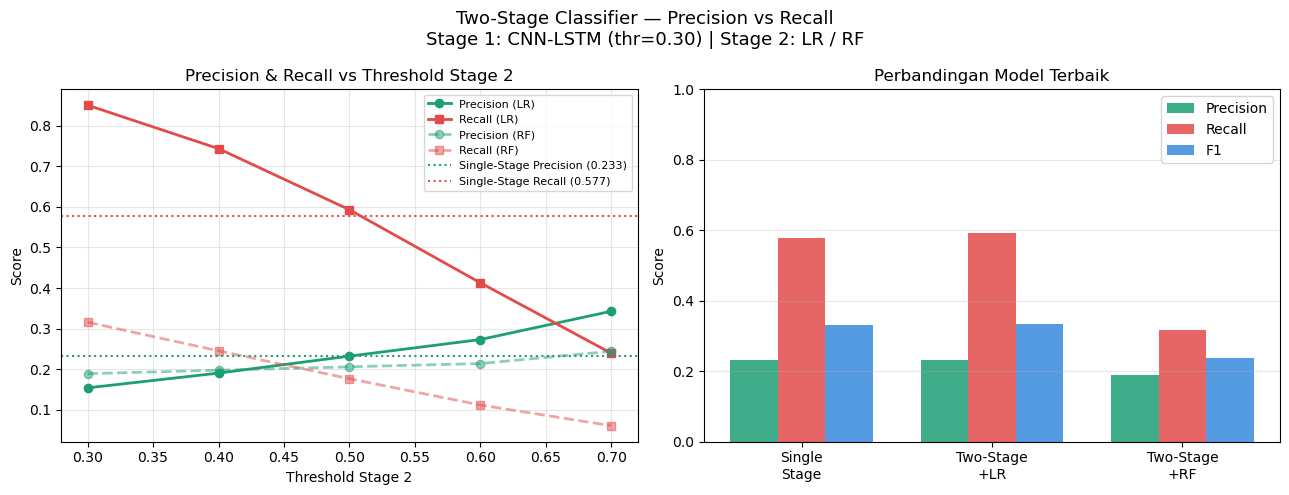

✅ Grafik disimpan ke two_stage_comparison.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Two-Stage Classifier — Precision vs Recall\n'
             'Stage 1: CNN-LSTM (thr=0.30) | Stage 2: LR / RF', fontsize=13)

# Kiri: precision & recall vs threshold Stage 2
thr_s2_vals = [r['thr_s2'] for r in res_lr]
axes[0].plot(thr_s2_vals, [r['precision'] for r in res_lr],
             'o-', lw=2, label='Precision (LR)', color='#1D9E75')
axes[0].plot(thr_s2_vals, [r['recall']    for r in res_lr],
             's-', lw=2, label='Recall (LR)',    color='#E24B4A')
axes[0].plot(thr_s2_vals, [r['precision'] for r in res_rf],
             'o--',lw=2, label='Precision (RF)', color='#1D9E75', alpha=0.5)
axes[0].plot(thr_s2_vals, [r['recall']    for r in res_rf],
             's--',lw=2, label='Recall (RF)',    color='#E24B4A', alpha=0.5)
axes[0].axhline(y=single_stage['precision'], color='#1D9E75',
                linestyle=':', label=f'Single-Stage Precision ({single_stage["precision"]:.3f})')
axes[0].axhline(y=single_stage['recall'], color='#E24B4A',
                linestyle=':', label=f'Single-Stage Recall ({single_stage["recall"]:.3f})')
axes[0].set_xlabel('Threshold Stage 2')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision & Recall vs Threshold Stage 2')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Kanan: bar chart perbandingan terbaik
models = ['Single\nStage', 'Two-Stage\n+LR', 'Two-Stage\n+RF']
precs  = [single_stage['precision'], best_lr['precision'], best_rf['precision']]
recs   = [single_stage['recall'],    best_lr['recall'],    best_rf['recall']]
f1s    = [single_stage['f1'],        best_lr['f1'],        best_rf['f1']]
x = np.arange(len(models))
w = 0.25
axes[1].bar(x-w, precs, w, label='Precision', color='#1D9E75', alpha=0.85)
axes[1].bar(x,   recs,  w, label='Recall',    color='#E24B4A', alpha=0.85)
axes[1].bar(x+w, f1s,   w, label='F1',        color='#378ADD', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_title('Perbandingan Model Terbaik')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('two_stage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan ke two_stage_comparison.png')

## 10. Classification Report Detail — Model Two-Stage Terbaik

Classification Report — Two-Stage Terbaik
Stage 1: CNN-LSTM (thr=0.30)
Stage 2: Logistic Regression (thr=0.50)

              precision    recall  f1-score   support

     Non-CHD       0.97      0.87      0.92     46214
         CHD       0.23      0.59      0.33      2991

    accuracy                           0.86     49205
   macro avg       0.60      0.73      0.63     49205
weighted avg       0.93      0.86      0.88     49205



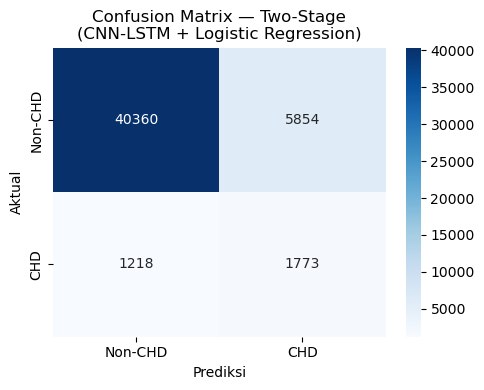

In [24]:
# Rekonstruksi prediksi final dengan model terbaik
best_model   = rf_stage2 if best_rf['f1'] > best_lr['f1'] else lr_stage2
best_thr_s2  = best_rf['thr_s2'] if best_rf['f1'] > best_lr['f1'] else best_lr['thr_s2']
best_s2_name = 'Random Forest' if best_rf['f1'] > best_lr['f1'] else 'Logistic Regression'

s2_proba = best_model.predict_proba(X_test_s2)[:, 1]
s2_pred  = (s2_proba >= best_thr_s2).astype(int)

y_final = np.zeros(len(y_test), dtype=int)
for i, idx in enumerate(idx_test_s2):
    y_final[idx] = s2_pred[i]

print(f'Classification Report — Two-Stage Terbaik')
print(f'Stage 1: CNN-LSTM (thr=0.30)')
print(f'Stage 2: {best_s2_name} (thr={best_thr_s2:.2f})')
print()
print(classification_report(y_test, y_final, target_names=['Non-CHD', 'CHD']))

# Confusion matrix
cm = confusion_matrix(y_test, y_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-CHD','CHD'], yticklabels=['Non-CHD','CHD'])
plt.title(f'Confusion Matrix — Two-Stage\n'
          f'(CNN-LSTM + {best_s2_name})')
plt.ylabel('Aktual'); plt.xlabel('Prediksi')
plt.tight_layout(); plt.show()

## 11. Analisis & Kesimpulan

In [26]:
print('='*70)
print('KESIMPULAN TWO-STAGE CLASSIFIER')
print('='*70)

best_two = best_rf if best_rf['f1'] > best_lr['f1'] else best_lr

delta_p = best_two['precision'] - single_stage['precision']
delta_r = best_two['recall']    - single_stage['recall']
delta_f = best_two['f1']        - single_stage['f1']

print(f'\nPerbandingan akhir:')
print(f'  Single-Stage   : P={single_stage["precision"]:.4f} R={single_stage["recall"]:.4f} F1={single_stage["f1"]:.4f}')
print(f'  Two-Stage best : P={best_two["precision"]:.4f} R={best_two["recall"]:.4f} F1={best_two["f1"]:.4f}')
print(f'  Delta Precision: {delta_p:+.4f}')
print(f'  Delta Recall   : {delta_r:+.4f}')
print(f'  Delta F1       : {delta_f:+.4f}')

print(f'\nInterpretasi:')
if delta_p > 0:
    print(f'  ✅ Presisi naik {delta_p*100:+.1f}% — Two-Stage berhasil mengurangi false positive')
else:
    print(f'  ⚠️ Presisi tidak naik — Two-Stage tidak memberikan perbaikan presisi')

if delta_r >= 0:
    print(f'  ✅ Recall naik {delta_r*100:+.1f}% — Two-Stage lebih sensitif')
elif delta_r > -0.10:
    print(f'  ✅ Recall turun {abs(delta_r)*100:.1f}% — trade-off yang masih wajar')
else:
    print(f'  ⚠️ Recall turun {abs(delta_r)*100:.1f}% — cukup signifikan')

print(f'\nKontribusi penelitian:')
print(f'  Two-Stage Classifier adalah pendekatan novel untuk deteksi CHD')
print(f'  dari data survei BRFSS yang belum pernah dieksplorasi di paper')
print(f'  sebelumnya (termasuk paper Pak Slamet yang hanya single-stage).')

KESIMPULAN TWO-STAGE CLASSIFIER

Perbandingan akhir:
  Single-Stage   : P=0.2326 R=0.5767 F1=0.3315
  Two-Stage best : P=0.2325 R=0.5928 F1=0.3340
  Delta Precision: -0.0001
  Delta Recall   : +0.0160
  Delta F1       : +0.0025

Interpretasi:
  ⚠️ Presisi tidak naik — Two-Stage tidak memberikan perbaikan presisi
  ✅ Recall naik +1.6% — Two-Stage lebih sensitif

Kontribusi penelitian:
  Two-Stage Classifier adalah pendekatan novel untuk deteksi CHD
  dari data survei BRFSS yang belum pernah dieksplorasi di paper
  sebelumnya (termasuk paper Pak Slamet yang hanya single-stage).


## 12. Simpan Hasil

In [28]:
# Simpan model Stage 2
joblib.dump(lr_stage2, 'model_stage2_lr.pkl')
joblib.dump(rf_stage2, 'model_stage2_rf.pkl')
print('✅ model_stage2_lr.pkl')
print('✅ model_stage2_rf.pkl')

# Simpan model Stage 1
stage1_model.save('model_stage1_cnn_lstm.keras')
print('✅ model_stage1_cnn_lstm.keras')

# Simpan hasil perbandingan
results_summary = {
    'single_stage': single_stage,
    'two_stage_lr_best': best_lr,
    'two_stage_rf_best': best_rf,
    'thr_stage1': THR_STAGE1,
    'features': MI_15_FEATURES,
}
joblib.dump(results_summary, 'two_stage_results.pkl')
print('✅ two_stage_results.pkl')

joblib.dump(scaler, 'scaler_mi15.pkl')
print('✅ scaler_mi15.pkl tersimpan')

print('\n========== RINGKASAN AKHIR ==========')
print(f'Arsitektur    : Two-Stage Classifier')
print(f'Stage 1       : CNN-LSTM MI k=15, threshold={THR_STAGE1}')
print(f'Stage 2 LR    : Logistic Regression, thr={best_lr["thr_s2"]:.2f}')
print(f'  -> P={best_lr["precision"]:.4f} R={best_lr["recall"]:.4f} F1={best_lr["f1"]:.4f}')
print(f'Stage 2 RF    : Random Forest, thr={best_rf["thr_s2"]:.2f}')
print(f'  -> P={best_rf["precision"]:.4f} R={best_rf["recall"]:.4f} F1={best_rf["f1"]:.4f}')
print(f'Single-Stage  : P={single_stage["precision"]:.4f} R={single_stage["recall"]:.4f} F1={single_stage["f1"]:.4f}')
print('=====================================')

✅ model_stage2_lr.pkl
✅ model_stage2_rf.pkl
✅ model_stage1_cnn_lstm.keras
✅ two_stage_results.pkl
✅ scaler_mi15.pkl tersimpan

========== RINGKASAN AKHIR ==========
Arsitektur    : Two-Stage Classifier
Stage 1       : CNN-LSTM MI k=15, threshold=0.3
Stage 2 LR    : Logistic Regression, thr=0.50
  -> P=0.2325 R=0.5928 F1=0.3340
Stage 2 RF    : Random Forest, thr=0.30
  -> P=0.1892 R=0.3159 F1=0.2367
Single-Stage  : P=0.2326 R=0.5767 F1=0.3315
